# Homework Assignment 5 - Sample Solution


RV model fitting resource:

https://docs.exoplanet.codes/en/v0.4.5/tutorials/intro-to-pymc3/#A-more-realistic-example:-radial-velocity-exoplanets

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook
%matplotlib inline

In [2]:
import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import corner

# from IPython.display import Image

import pymc as pm
from pymc.model.fgraph import clone_model

from scipy import stats
from scipy.special import expit

import pytensor.tensor as pt

import jax                                                     
import jax.numpy as jnp                                      
jax.config.update("jax_enable_x64", True)                
import jaxopt 

import exoplanet as xo

from IPython.display import display, HTML
display(HTML("<style>.container {width:80% !important; }</style>"))

In [3]:
def setup():
    
    # Control tickers
    plt.rcParams['xtick.top']           = True
    plt.rcParams['xtick.bottom']        = True
    plt.rcParams['xtick.top']           = True
    plt.rcParams['xtick.labelbottom']   = True
    plt.rcParams['xtick.direction']     = 'out'
    plt.rcParams['xtick.minor.visible'] = True
    plt.rcParams['xtick.major.top']     = True
    plt.rcParams['xtick.minor.top']     = True
    plt.rcParams['xtick.minor.bottom']  = True
    plt.rcParams['xtick.alignment']     = 'center'
    plt.rcParams['ytick.left']          = True
    plt.rcParams['ytick.right']         = True
    plt.rcParams['ytick.labelleft']     = True
    plt.rcParams['ytick.minor.visible'] = True
    plt.rcParams['ytick.major.left']    = True
    plt.rcParams['ytick.major.right']   = True
    plt.rcParams['ytick.minor.left']    = True
    plt.rcParams['ytick.minor.right']   = True

    # Legends
    plt.rcParams['legend.loc']        = 'best'
    plt.rcParams['legend.frameon']    = True
    plt.rcParams['legend.fancybox']   = True
    plt.rcParams['legend.framealpha'] = 0.8
    plt.rcParams['legend.fontsize']   = 15

    # Font
    plt.rcParams['font.family']    = 'serif'
    plt.rcParams['font.size']      = 17
    plt.rcParams['axes.titlesize'] = 17
        
def latex():    
    setup()
    # Check if LaTeX is installed
    plt.rcParams['text.usetex'] = True
    

        
def setup_notebook():
    setup()
    latex()

setup_notebook()

In [4]:
# Global paths
path = '/lhome/nicholas/software/workdir/smbhb'
fdir = '/lhome/nicholas/Nextcloud/latex/paperSMBHB/figures'

# Example

In [5]:
# Download the dataset from the Exoplanet Archive:
url = "https://exoplanetarchive.ipac.caltech.edu/data/ExoData/0113/0113357/data/UID_0113357_RVC_001.tbl"
r = requests.get(url)
if r.status_code != requests.codes.ok:
    r.raise_for_status()
data = np.array(
    [
        l.split()
        for l in r.text.splitlines()
        if not l.startswith("\\") and not l.startswith("|")
    ],
    dtype=float,
)
t, rv, rv_err = data.T
t -= np.mean(t)

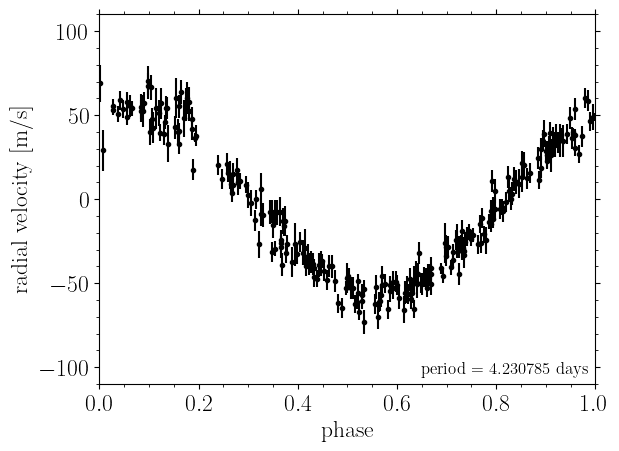

In [6]:
# Plot the observations "folded" on the published period:
# Butler et al. (2006) https://arxiv.org/abs/astro-ph/0607493
lit_period = 4.230785
plt.errorbar(
    (t % lit_period) / lit_period, rv, yerr=rv_err, fmt=".k", capsize=0
)
plt.xlim(0, 1)
plt.ylim(-110, 110)
plt.annotate(
    "period = {0:.6f} days".format(lit_period),
    xy=(1, 0),
    xycoords="axes fraction",
    xytext=(-5, 5),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=12,
)
plt.ylabel("radial velocity [m/s]")
_ = plt.xlabel("phase")

In [7]:
with pm.Model() as model:
    
    # Parameters
    logK = pm.Uniform(
        "logK",
        lower=0,
        upper=np.log(200),
        initval=np.log(0.5 * (np.max(rv) - np.min(rv))),
    )
    logP = pm.Uniform(
        "logP", lower=0, 
        upper=np.log(20), 
        initval=np.log(lit_period)
    )
    phi = pm.Uniform("phi", 
                     lower=0, 
                     upper=2 * np.pi, 
                     initval=0.1)

    # Parameterize the eccentricity using:
    #  h = sqrt(e) * sin(w)
    #  k = sqrt(e) * cos(w)
    h, k = xo.unit_disk("h", "k", initval=np.array([0.01, 0.01]))
    e = pm.Deterministic("e", h**2 + k**2)
    w = pm.Deterministic("w", pt.arctan2(k, h))

    rv0 = pm.Normal("rv0", mu=0.0, sigma=10.0, initval=0.0)
    rvtrend = pm.Normal("rvtrend", mu=0.0, sigma=10.0, initval=0.0)

    # Deterministic transformations
    n = 2 * np.pi * pt.exp(-logP)
    P = pm.Deterministic("P", pt.exp(logP))
    K = pm.Deterministic("K", pt.exp(logK))
    cosw = pt.cos(w)
    sinw = pt.sin(w)
    t0 = (phi + w) / n

    # The RV model
    bkg = pm.Deterministic("bkg", rv0 + rvtrend * t / 365.25)
    M = n * t - (phi + w)

    # This is the line that uses the custom Kepler solver
    f = xo.orbits.get_true_anomaly(M, e + pt.zeros_like(M))
    rvmodel = pm.Deterministic(
        "rvmodel", bkg + K * (cosw * (pt.cos(f) + e) - sinw * pt.sin(f))
    )

    # Condition on the observations
    pm.Normal("obs", mu=rvmodel, sigma=rv_err, observed=rv)

    # Compute the phased RV signal
    phase = np.linspace(0, 1, 500)
    M_pred = 2 * np.pi * phase - (phi + w)
    f_pred = xo.orbits.get_true_anomaly(M_pred, e + pt.zeros_like(M_pred))
    rvphase = pm.Deterministic(
        "rvphase", K * (cosw * (pt.cos(f_pred) + e) - sinw * pt.sin(f_pred))
    )

In [8]:
with model:
    map_params = pm.find_MAP()

Output()

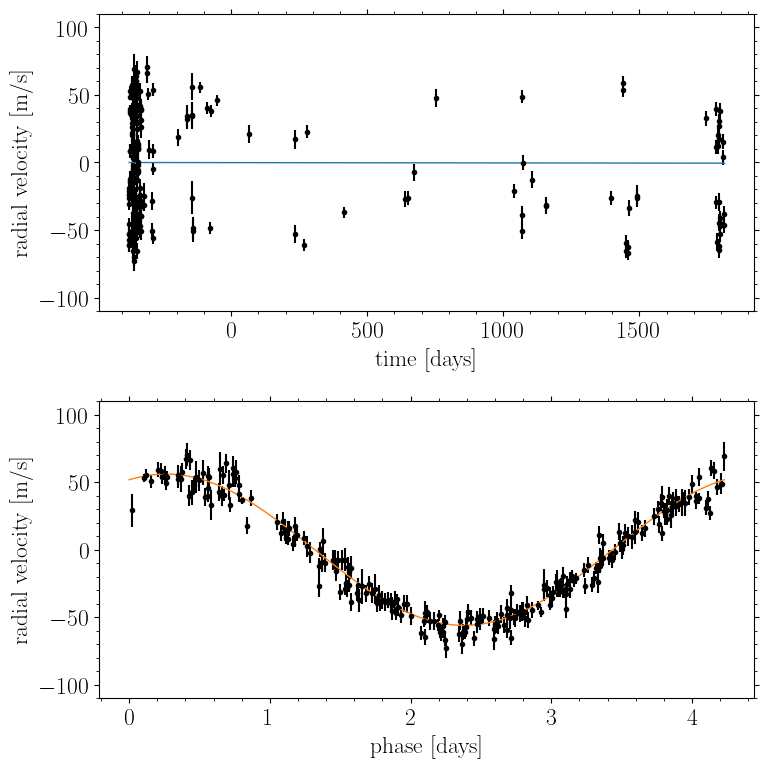

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

period = map_params["P"]

ax = axes[0]
ax.errorbar(t, rv, yerr=rv_err, fmt=".k")
ax.plot(t, map_params["bkg"], color="C0", lw=1)
ax.set_ylim(-110, 110)
ax.set_ylabel("radial velocity [m/s]")
ax.set_xlabel("time [days]")

ax = axes[1]
ax.errorbar(t % period, rv - map_params["bkg"], yerr=rv_err, fmt=".k")
ax.plot(phase * period, map_params["rvphase"], color="C1", lw=1)
ax.set_ylim(-110, 110)
ax.set_ylabel("radial velocity [m/s]")
ax.set_xlabel("phase [days]")

plt.tight_layout()

In [10]:
with model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        initvals=map_params,
        chains=2,
        cores=2,
        target_accept=0.95,
        init="adapt_full",
    )

Initializing NUTS using adapt_full...
/lhome/nicholas/anaconda3/envs/favoritecourse/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [logK, logP, phi, h, __k_unit_disk, rv0, rvtrend]


Output()

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 7 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [11]:
az.summary(
    trace,
    var_names=["logK", "logP", "phi", "e", "w", "rv0", "rvtrend"],
)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
logK,4.019,0.010,4.001,4.036,0.000,0.000,1797.0,1300.0,1.0
logP,1.442,0.000,1.442,1.442,0.000,0.000,1922.0,1583.0,1.0
phi,0.397,0.010,0.378,0.415,0.000,0.000,1696.0,1267.0,1.0
e,0.010,0.008,0.000,0.024,0.000,0.000,1381.0,1389.0,1.0
w,0.583,1.408,-2.296,3.108,0.036,0.025,1615.0,1684.0,1.0
rv0,-1.822,0.383,-2.494,-1.028,0.009,0.009,1984.0,1408.0,1.0
rvtrend,-1.590,0.188,-1.928,-1.231,0.004,0.004,1873.0,1523.0,1.0


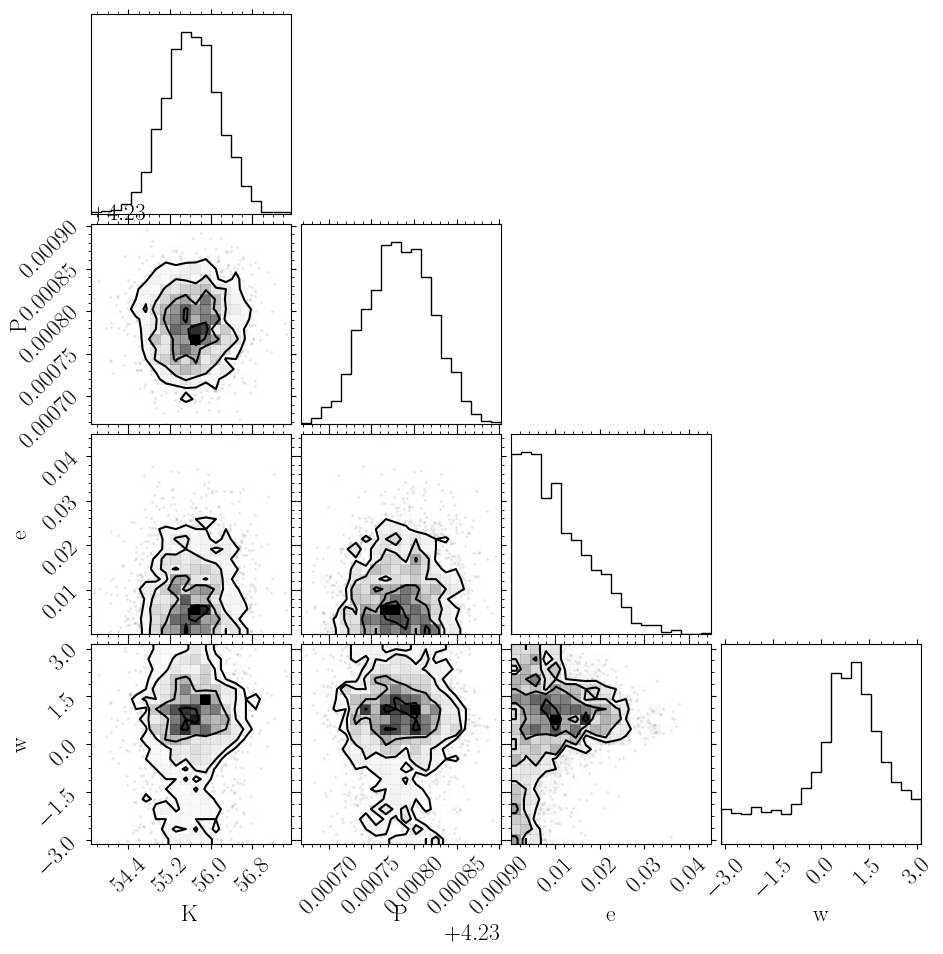

In [12]:
_ = corner.corner(trace, var_names=["K", "P", "e", "w"])

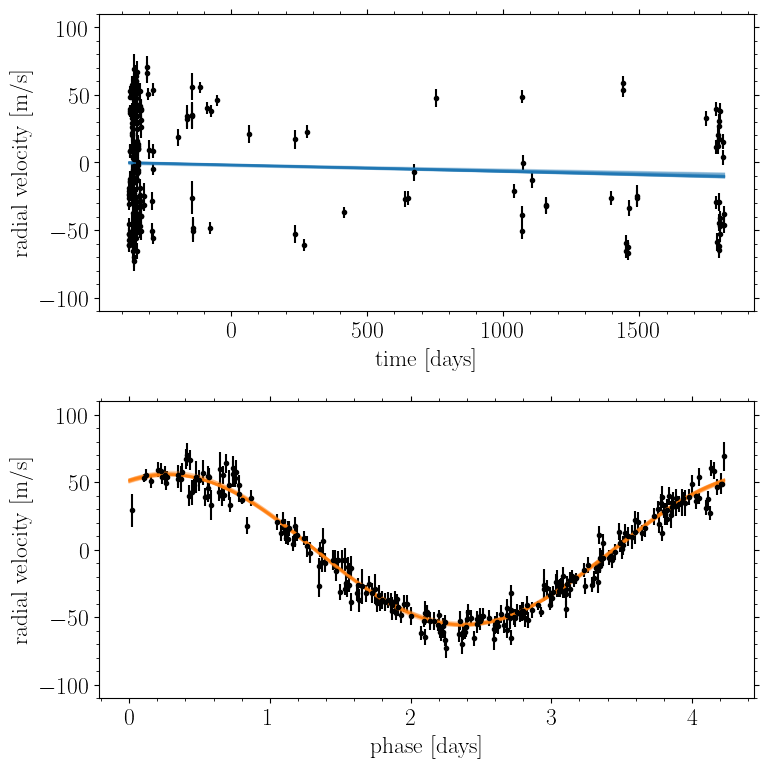

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

period = map_params["P"]

ax = axes[0]
ax.errorbar(t, rv, yerr=rv_err, fmt=".k")
ax.set_ylabel("radial velocity [m/s]")
ax.set_xlabel("time [days]")

ax = axes[1]
ax.errorbar(t % period, rv - map_params["bkg"], yerr=rv_err, fmt=".k")
ax.set_ylabel("radial velocity [m/s]")
ax.set_xlabel("phase [days]")

bkg = trace.posterior["bkg"].values
rvphase = trace.posterior["rvphase"].values

for ind in np.random.randint(np.prod(bkg.shape[:2]), size=25):
    i = np.unravel_index(ind, bkg.shape[:2])
    axes[0].plot(t, bkg[i], color="C0", lw=1, alpha=0.3)
    axes[1].plot(phase * period, rvphase[i], color="C1", lw=1, alpha=0.3)

axes[0].set_ylim(-110, 110)
axes[1].set_ylim(-110, 110)

plt.tight_layout()

---
# Spikey modelling
---

In [20]:
df = pd.read_feather(f'{path}/tests/lc_Spikey_mag16.ftr')
df = df.dropna()
df = df.iloc[::1]
t = df.time.to_numpy() / 86400
rv = df.flux.to_numpy()
t -= np.mean(t)
rv_err = 10 * np.ones(len(rv))

z = 0.926
P = 1.444 * 365.25
T = P * (1+z) 
period = T
e = 0.524
w =1.477
h = np.sqrt(e) * np.sin(w)
k = np.sqrt(e) * np.cos(w)
h, k

(np.float64(0.720696525552044), np.float64(0.06779762574907791))

In [21]:
varfile = f'{path}/varsource/varsource_spikey.txt'
dv = pd.read_csv(varfile, sep=' ', names=['time', 'dmag'])
dv['flux'] = (10**(-dv.dmag/2.5) - 1) * 1e3
dv['time'] /= 86400
dv.time -= np.mean(dv.time) - 48 #+ (dv.time.max()-t.max()))

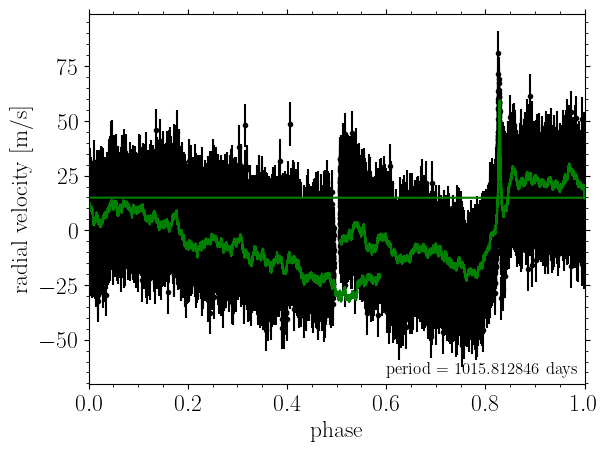

In [22]:
# Plot the observations "folded" on the published period:
# Butler et al. (2006) https://arxiv.org/abs/astro-ph/0607493
plt.errorbar( (t % period) / period, rv, yerr=rv_err, fmt=".k", capsize=0, zorder=1)
plt.plot((dv.time % period) / period, dv.flux, 'g-', zorder=2)
plt.xlim(0, 1)
plt.annotate(
    "period = {0:.6f} days".format(period),
    xy=(1, 0),
    xycoords="axes fraction",
    xytext=(-5, 5),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=12,
)
plt.ylabel("radial velocity [m/s]")
plt.xlabel("phase");

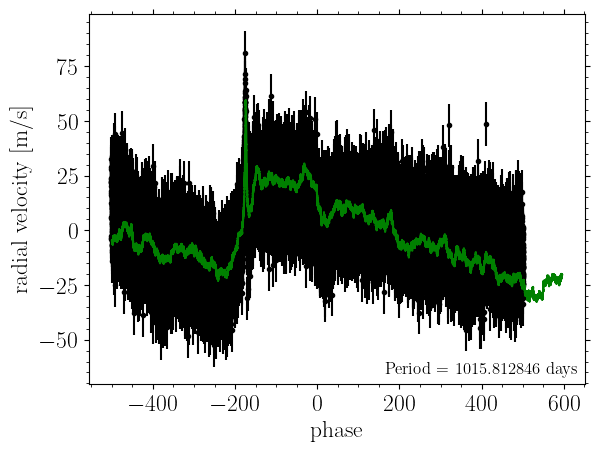

In [23]:
# Plot the observations "folded" on the published period:
plt.errorbar(t, rv, yerr=rv_err, fmt=".k", capsize=0, zorder=1)
plt.plot(dv.time, dv.flux, 'g-', zorder=2)

plt.annotate(
    "Period = {0:.6f} days".format(period),
    xy=(1, 0),
    xycoords="axes fraction",
    xytext=(-5, 5),
    textcoords="offset points",
    ha="right",
    va="bottom",
    fontsize=12,
)
plt.ylabel("radial velocity [m/s]")
_ = plt.xlabel("phase")

## Model Doppler boosting

In [24]:
with pm.Model() as model:
    
    # Parameters
    logK = pm.Uniform(
        "logK", 
        lower=0,
        upper=np.log(200),
        initval=np.log(0.5 * (np.max(rv) - np.min(rv))),
    )
    logP = pm.Uniform(
        "logP", 
        lower=0, 
        upper=np.log(1500), 
        initval=np.log(period))
    phi = pm.Uniform(
        "phi", 
        lower=0, 
        upper=2 * np.pi, 
        initval=0.1)

    # Parameterize the eccentricity using:
    #  h = sqrt(e) * sin(w)
    #  k = sqrt(e) * cos(w)
    h, k = xo.unit_disk("h", "k", initval=np.array([0.7, 0.06]))
    e = pm.Deterministic("e", h**2 + k**2)
    w = pm.Deterministic("w", pt.arctan2(k, h))

    # RV signal
    rvtrend = pm.Normal("rvtrend", mu=0.0, sigma=10.0, initval=0.0)

    # Deterministic transformations
    n = 2 * np.pi * pt.exp(-logP)
    P = pm.Deterministic("P", pt.exp(logP))
    K = pm.Deterministic("K", pt.exp(logK))
    cosw = pt.cos(w)
    sinw = pt.sin(w)
    t0 = (phi + w) / n

    # The RV model
    M = n * t - (phi + w)
    bkg = pm.Deterministic("bkg", rvtrend * t / 365.25)

    # This is the line that uses the custom Kepler solver
    f = xo.orbits.get_true_anomaly(M, e + pt.zeros_like(M))
    rvmodel = pm.Deterministic("rvmodel", bkg + K * (cosw * (pt.cos(f) + e) - sinw * pt.sin(f)) )

    # Condition on the observations
    pm.Normal("obs", mu=rvmodel, sigma=rv_err, observed=rv)

    # Compute the phased RV signal
    phase = np.linspace(0, 1, 500)
    M_pred = 2 * np.pi * phase - (phi + w)
    f_pred = xo.orbits.get_true_anomaly(M_pred, e + pt.zeros_like(M_pred))
    rvphase = pm.Deterministic("rvphase", K * (cosw * (pt.cos(f_pred) + e) - sinw * pt.sin(f_pred)))

In [25]:
with model:
    map_params = pm.find_MAP()

Output()

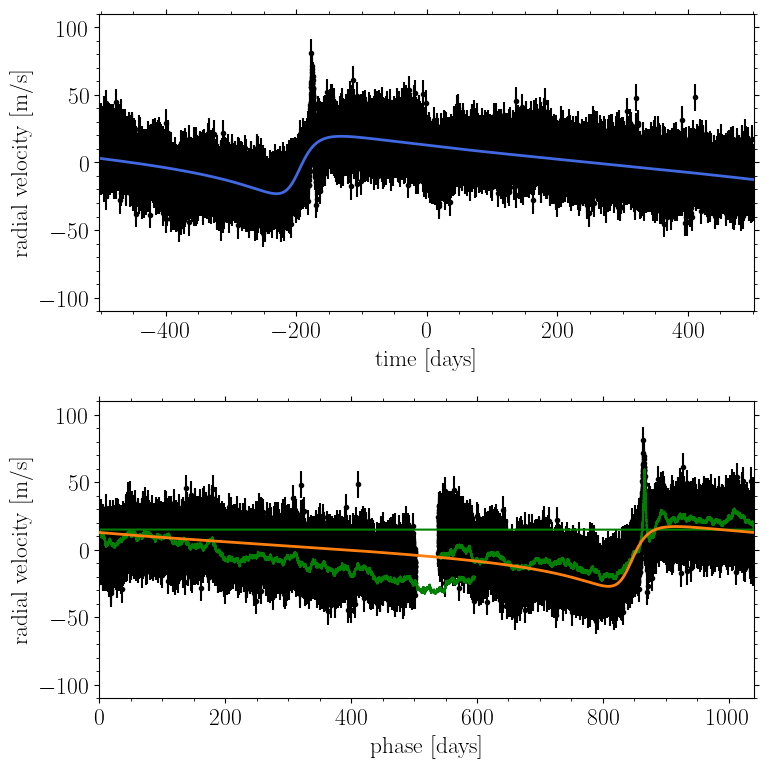

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

period = map_params["P"]

ax = axes[0]
ax.errorbar(t, rv, yerr=rv_err, fmt=".k", zorder=1)
ax.plot()
ax.plot(t, map_params["rvmodel"], color="royalblue", lw=2, zorder=2)
ax.set_ylim(-110, 110)
ax.set_ylabel("radial velocity [m/s]")
ax.set_xlabel("time [days]")

ax = axes[1]
ax.errorbar(t % period, rv, yerr=rv_err, fmt=".k", zorder=1)
ax.plot(dv.time % period, dv.flux, 'g-', zorder=2)
ax.plot(phase * period, map_params["rvphase"], color="C1", lw=2, zorder=3)
ax.set_ylim(-110, 110)
ax.set_ylabel("radial velocity [m/s]")
ax.set_xlabel("phase [days]")

axes[0].set_xlim(min(t), max(t))
axes[1].set_xlim(min(t % period), max(t % period))

plt.tight_layout()

In [27]:
with model:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        initvals=map_params,
        chains=4,
        cores=4,
        target_accept=0.95,
        init="adapt_full")

Initializing NUTS using adapt_full...
/lhome/nicholas/anaconda3/envs/favoritecourse/lib/python3.10/site-packages/pymc/step_methods/hmc/quadpotential.py:760: UserWarning: QuadPotentialFullAdapt is an experimental feature
  warnings.warn("QuadPotentialFullAdapt is an experimental feature")
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [logK, logP, phi, h, __k_unit_disk, rvtrend]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 107 seconds.


In [28]:
az.summary(trace,var_names=["logK", "logP", "phi", "e", "w", "rvtrend"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
logK,3.097,0.007,3.083,3.110,0.000,0.000,4859.0,2623.0,1.0
logP,6.948,0.013,6.924,6.971,0.000,0.000,4007.0,2788.0,1.0
phi,0.697,0.018,0.663,0.731,0.000,0.000,4057.0,2934.0,1.0
e,0.700,0.004,0.693,0.708,0.000,0.000,5447.0,3216.0,1.0
w,-1.897,0.011,-1.917,-1.875,0.000,0.000,5475.0,2724.0,1.0
rvtrend,-6.308,0.209,-6.700,-5.921,0.003,0.003,4095.0,2831.0,1.0


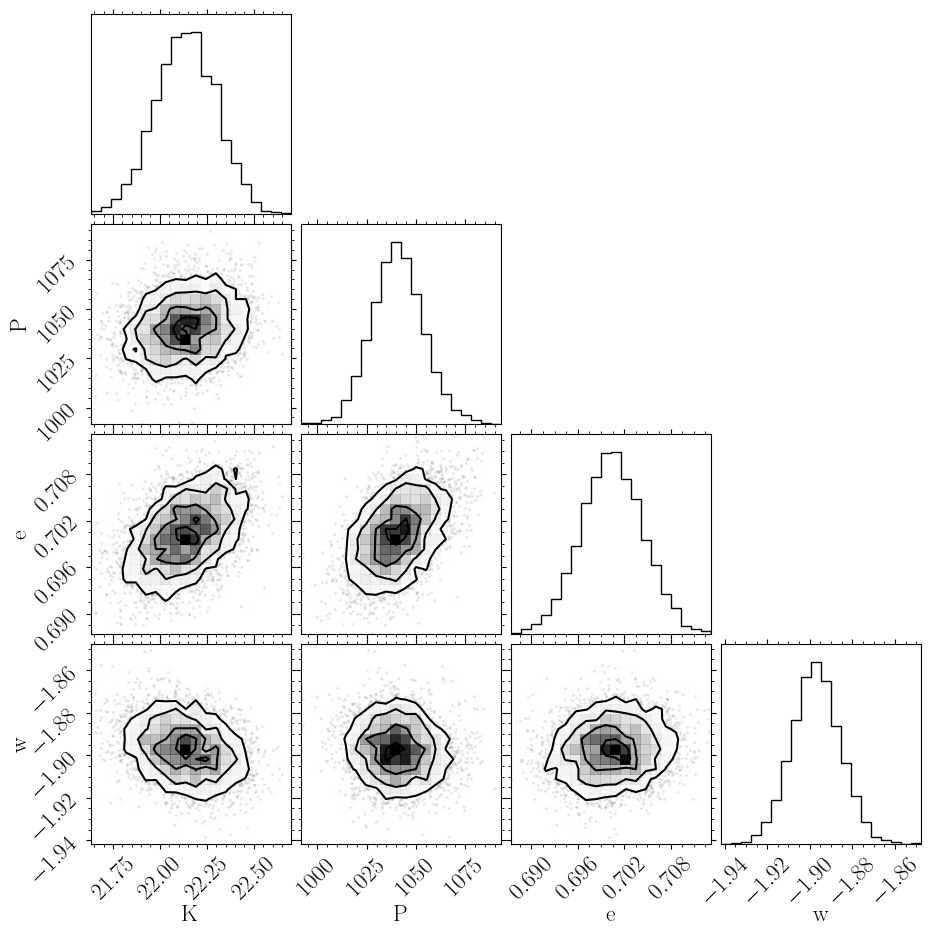

In [29]:
_ = corner.corner(trace, var_names=["K", "P", "e", "w"])

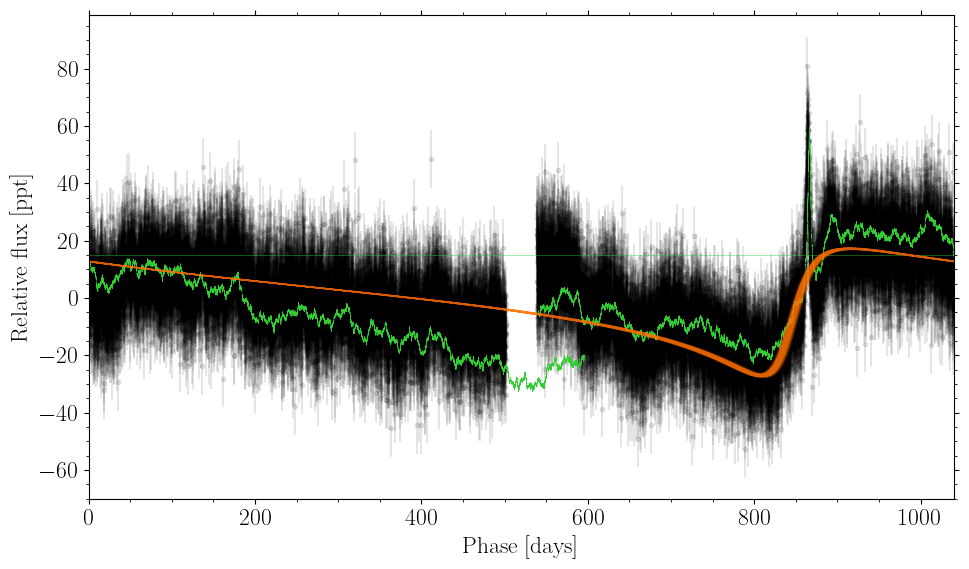

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

period = map_params["P"]

ax.errorbar(t % period, rv, yerr=rv_err, fmt=".k", alpha=0.1, zorder=1)
ax.plot(dv.time % period, dv.flux, '-', c='limegreen', lw=0.3, zorder=2)
ax.set_ylabel("Relative flux [ppt]")
ax.set_xlabel("Phase [days]")

rvphase = trace.posterior["rvphase"].values
for dex in range(1000):
    i = np.unravel_index(dex, rvtrend.shape[:2])
    ax.plot(phase * period, rvphase[i], color="C1", lw=0.2, alpha=0.1)

ax.set_xlim(min(t % period), max(t % period))
plt.tight_layout()

# fig.savefig(f'{fdir}/lc_spikey_model_.png', bbox_inches='tight', dpi=300)

---
## With RV0 trend

In [433]:
with pm.Model() as model:
    
    # Parameters
    logK = pm.Uniform(
        "logK", 
        lower=0,
        upper=np.log(200),
        initval=np.log(0.5 * (np.max(rv) - np.min(rv))))
    logP = pm.Uniform(
        "logP", 
        lower=0, 
        upper=np.log(1000), 
        initval=np.log(period))
    phi = pm.Uniform(
        "phi", 
        lower=0, 
        upper=2 * np.pi, 
        initval=0.1)

    # Parameterize the eccentricity using:
    #  h = sqrt(e) * sin(w)
    #  k = sqrt(e) * cos(w)
    h, k = xo.unit_disk("h", "k", initval=np.array([0.7, 0.06]))
    e = pm.Deterministic("e", h**2 + k**2)
    w = pm.Deterministic("w", pt.arctan2(k, h))

    rv0 = pm.Normal("rv0", mu=0.0, sigma=10.0, initval=0.0)
    rvtrend = pm.Normal("rvtrend", mu=0.0, sigma=10.0, initval=0.0)

    # Deterministic transformations
    n = 2 * np.pi * pt.exp(-logP)
    P = pm.Deterministic("P", pt.exp(logP))
    K = pm.Deterministic("K", pt.exp(logK))
    cosw = pt.cos(w)
    sinw = pt.sin(w)
    t0 = (phi + w) / n

    # The RV model
    # bkg = pm.Deterministic("bkg", rv0 + rvtrend * t / 365.25)
    bkg = pm.Deterministic("bkg", rvtrend * t / 365.25)

    M = n * t - (phi + w)

    # This is the line that uses the custom Kepler solver
    f = xo.orbits.get_true_anomaly(M, e + pt.zeros_like(M))
    rvmodel = pm.Deterministic("rvmodel", bkg + K * (cosw * (pt.cos(f) + e) - sinw * pt.sin(f)) )

    # Condition on the observations
    pm.Normal("obs", mu=rvmodel, sigma=rv_err, observed=rv)

    # Compute the phased RV signal
    phase = np.linspace(0, 1, 500)
    M_pred = 2 * np.pi * phase - (phi + w)
    f_pred = xo.orbits.get_true_anomaly(M_pred, e + pt.zeros_like(M_pred))
    rvphase = pm.Deterministic("rvphase", K * (cosw * (pt.cos(f_pred) + e) - sinw * pt.sin(f_pred)))

In [434]:
with model:
    map_params = pm.find_MAP()

Output()

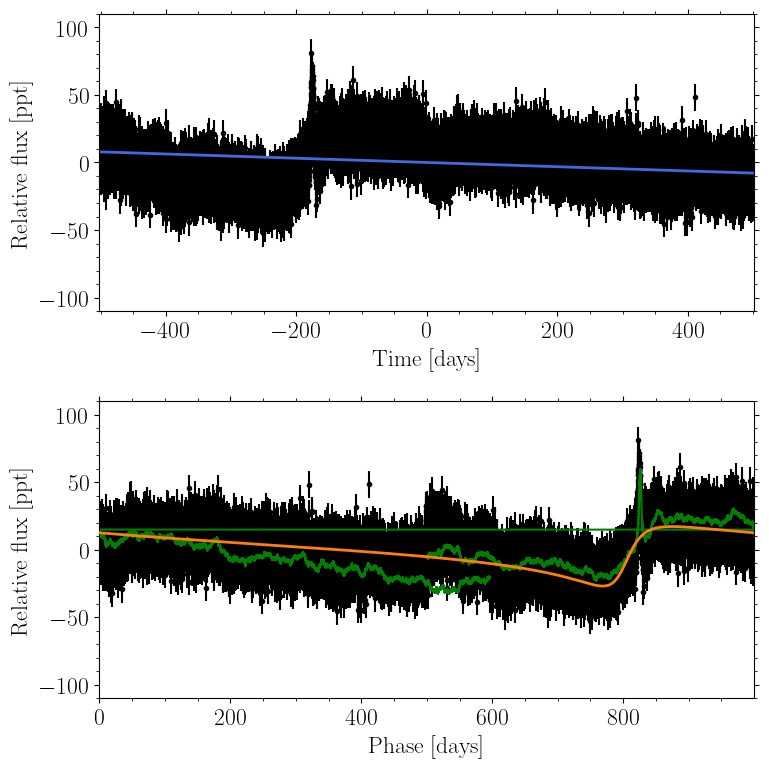

In [435]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))

period = map_params["P"]

ax = axes[0]
ax.errorbar(t, rv, yerr=rv_err, fmt=".k", zorder=1)
ax.plot()
ax.plot(t, map_params["bkg"], color="royalblue", lw=2, zorder=2)
ax.set_ylim(-110, 110)
ax.set_ylabel("Relative flux [ppt]")
ax.set_xlabel("Time [days]")

ax = axes[1]
ax.errorbar(t % period, rv, yerr=rv_err, fmt=".k", zorder=1)
ax.plot(dv.time % period, dv.flux, 'g-', zorder=2)
ax.plot(phase * period, map_params["rvphase"], color="C1", lw=2, zorder=3)
ax.set_ylim(-110, 110)
ax.set_ylabel("Relative flux [ppt]")
ax.set_xlabel("Phase [days]")

axes[0].set_xlim(min(t), max(t))
axes[1].set_xlim(min(t % period), max(t % period))

plt.tight_layout()

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7))

period = map_params["P"]

ax = axes[0]
ax.errorbar(t, rv, yerr=rv_err, fmt=".k", alpha=0.2, zorder=1)
ax.set_ylabel("Relative flux [ppt]")
ax.set_xlabel("Time [days]")

ax = axes[1]
ax.errorbar(t % period, rv - map_params["bkg"], yerr=rv_err, fmt=".k", alpha=0.1, zorder=1)
ax.plot(dv.time % period, dv.flux, '-', c='limegreen', lw=0.3, zorder=2)
ax.set_ylabel("Relative flux [ppt]")
ax.set_xlabel(r"Phase $\times$ Period [days]")

bkg = trace.posterior["bkg"].values
rvphase = trace.posterior["rvphase"].values

for ind in np.random.randint(np.prod(bkg.shape[:2]), size=25):
    i = np.unravel_index(ind, bkg.shape[:2])
    axes[0].plot(t, bkg[i], color="C0", lw=1, alpha=0.3)
    axes[1].plot(phase * period, rvphase[i], color="C1", lw=1, alpha=0.5)

axes[0].set_xlim(min(t), max(t))
axes[1].set_xlim(min(t % period), max(t % period))

plt.tight_layout()
ax.set_xlabel(r"Phase $\times$ Period [days]")

fig.savefig(f'{fdir}/modelfit_spikey_mag16.png', bbox_inches='tight', dpi=300)